In [21]:
import pandas as pd
import numpy as np
from NSGA2 import NSGA2_FS
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from IAMB import IAMB
from clustering import DBSCAN_Clustering

In [25]:
def generate_dataset(n_samples, n_features, n_informative, n_redundant, n_repeated, n_classes):
    X, y = make_classification(
        n_samples = n_samples,
        n_features = n_features,
        n_informative = n_informative,   
        n_redundant = n_redundant,      
        n_repeated = n_repeated,
        n_classes = n_classes,
        random_state=42,
        shuffle = False
    )

    feature_cols = [f"feature_{i+1}" for i in range(X.shape[1])]
    df = pd.DataFrame(X, columns=feature_cols)
    df["target"] = y
    return df

## <h1>Observations and Results 
<h3>(Small data - low samples + low no of features)

In [12]:
data = generate_dataset(n_samples = 1000, n_features = 50, n_informative = 2, n_redundant = 2, n_repeated = 1, n_classes = 2)
data

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,feature_50,target
0,-1.050478,-1.323568,0.912474,1.009796,0.912474,-0.154925,0.700736,-0.278391,0.633361,-1.540793,...,-0.858450,1.125588,-0.272975,-0.777539,0.728685,-0.488197,1.027422,-0.663720,-0.159595,0
1,-1.580834,-2.747104,1.777419,1.850430,1.777419,0.944972,-0.226261,0.756053,-0.065548,1.981692,...,-0.417964,1.274592,0.810062,1.075176,-1.368705,1.548000,-0.761408,0.192293,-0.148223,0
2,-0.885704,-0.614600,0.501004,0.631813,0.501004,-0.878483,-1.412536,-1.743848,0.119018,-1.525319,...,1.671483,-0.107559,-0.695044,-0.041169,0.537091,0.051626,-0.205728,-0.650017,-0.662131,0
3,-1.525438,-2.967793,1.884777,1.924410,1.884777,-0.597808,0.338815,-0.994180,0.393269,1.412995,...,0.331844,-0.423776,-1.617363,-0.716640,0.157055,0.162744,0.041379,0.548708,-0.581146,0
4,-1.076826,-1.014619,0.752233,0.885267,0.752233,0.026681,0.572093,-0.084890,-1.243324,-0.961488,...,0.406477,-1.579616,1.378710,-1.244831,-0.710081,-0.597710,-1.526271,0.032576,0.213904,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.792945,0.687195,-0.521841,-0.625632,-0.521841,0.519147,-1.884094,1.280781,0.874839,-0.356611,...,-0.240889,0.142886,0.298590,1.090375,0.778570,0.951085,-0.352021,0.287708,1.734886,1
996,1.063154,0.887385,-0.681478,-0.823942,-0.681478,-0.096858,0.129330,0.142710,-0.103958,1.288156,...,-0.537584,0.544619,1.088981,1.980982,-1.864282,-1.027763,-0.342131,0.556130,0.764410,1
997,0.244362,0.231442,-0.171343,-0.201416,-0.171343,-1.178801,0.376374,-2.559875,0.291922,-0.026137,...,1.784793,-0.364092,-1.261689,-1.190092,1.036209,-1.686562,0.063828,-0.176226,-0.675419,1
998,1.777667,1.742310,-1.277857,-1.490927,-1.277857,-0.858359,0.696159,0.777406,1.167324,0.484341,...,-0.136359,0.314154,-0.121295,-0.205613,-0.492848,-1.889007,1.767494,0.197976,-0.081504,0


In [13]:
nsga = NSGA2_FS(classifier = 'decisiontree', population_size = 200)
nsga.fit(data)


Classifier      : decisiontree
Population size : 200
Number of fronts: 31

  Rank 1 -- 4 individual(s):
    individual  62 | features: 19 | accuracy: 0.8690
    individual  69 | features: 18 | accuracy: 0.8480
    individual  94 | features: 17 | accuracy: 0.5090
    individual 192 | features: 20 | accuracy: 0.8930
  Rank 2 -- 4 individual(s):
    individual 118 | features: 19 | accuracy: 0.8190
    individual 171 | features: 18 | accuracy: 0.7780
    individual  51 | features: 22 | accuracy: 0.8920
    individual  95 | features: 20 | accuracy: 0.8850
  Rank 3 -- 5 individual(s):
    individual  22 | features: 19 | accuracy: 0.8040
    individual 164 | features: 22 | accuracy: 0.8910
    individual 185 | features: 26 | accuracy: 0.8920
    individual  81 | features: 21 | accuracy: 0.8840
    individual 176 | features: 20 | accuracy: 0.8730
  Rank 4 -- 6 individual(s):
    individual 193 | features: 19 | accuracy: 0.0000
    individual   6 | features: 24 | accuracy: 0.8880
    individua

In [16]:
sol = nsga.find_knee_point(nsga.pareto_front_)
print(sol.mask_features, sol.obj_scores[0], sol.obj_scores[1])

[ True  True False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False] 2 0.9029999999999999


<b>NSGA 2 Alone takes a average time of 6 mins for a dataset with 50 features, 1000 samples and for 200 generations

eps calculated through elbow curve:  0.9079307887108519


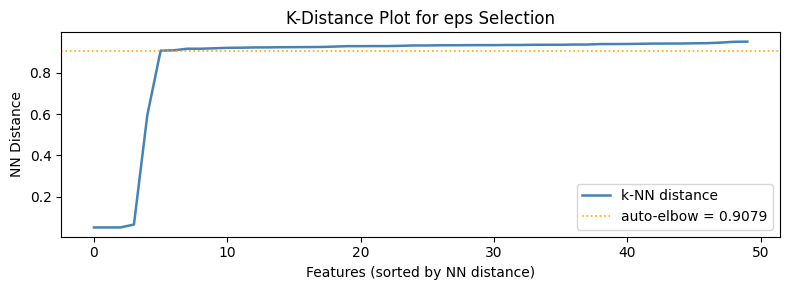

Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108519
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9079307887108519
Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108519
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9079307887108519
Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108519
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9079307887108519
Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108519
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9079307887108519
Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108519
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.9079307887108519
Clusters found : 4
Noise features : 38  (76.0%)
eps increased to:  0.9579307887108519
Clusters found : 1
Noise features : 0  (0.0%)
eps decreased to  0.907

InvalidIndexError: (slice(None, None, None), [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [26]:
feature_cols = data.columns
model = DBSCAN_Clustering()
model.build_distance_matrix(data.iloc[:,:-1].values)          
model.cluster_features(feature_names=feature_cols)

print("\nCluster assignments:")
for cid, idxs in model.clusters.items():
    names = [feature_cols[i] for i in idxs]
    print(f"  Cluster {cid}: {names}")
if model.noise:
    noise_names = [feature_cols[i] for i in model.noise]
    print(f"  Noise features: {noise_names}")

X_train, X_test, y_train, y_test = train_test_split(data.iloc[:,:-1], data.iloc[:,-1], test_size=0.2, random_state=42)

iamb = IAMB(alpha=0.01, n_bins=10)
selected = iamb.run(model.clusters, X_train,y_train)
selected_feature_names=[feature_cols[i] for i in selected]
print("\nSelected from clusters:", selected)
print("Selected feature names:", selected_feature_names)
print("length of selected features: ",len(selected_feature_names))